# KNN Song Recommendation Model

This notebook builds a K-Nearest Neighbors model to recommend similar songs based on audio features.

**Note:** Make sure to run [eda.ipynb](eda.ipynb) first to generate the deduplicated `tracks_processed.csv` file.

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed dataset
df = pd.read_csv('data/tracks_processed.csv')
print(f"Dataset loaded: {df.shape}")
print(f"Features: {df.columns.tolist()}")
df.head()

Dataset loaded: (89740, 10)
Features: ['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'danceability', 'energy', 'loudness', 'valence', 'tempo']


,track_id,track_name,artists,album_name,track_genre,danceability,energy,loudness,valence,tempo
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,0.686294,0.4610,0.791392,0.718593,0.361245
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,0.426396,0.1660,0.597377,0.268342,0.318397
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,0.444670,0.3590,0.736123,0.120603,0.313643
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,0.270051,0.0596,0.573701,0.143719,0.746758
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,Hold On,acoustic,0.627411,0.4430,0.737103,0.167839,0.492863


## Prepare Feature Matrix

Extract the normalized audio features for KNN training.

In [ ]:
# Define feature columns (9 features, already normalized with StandardScaler)
feature_cols = ['danceability', 'energy', 'loudness', 'valence', 'tempo',
                'acousticness', 'instrumentalness', 'speechiness', 'liveness']

# Extract feature matrix
X = df[feature_cols].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {feature_cols}")

## Build KNN Model

Using euclidean distance with 10 neighbors for optimal performance.

In [ ]:
# Build KNN model
# metric='euclidean' works best with StandardScaler normalization
# n_neighbors=11 because the first neighbor is the song itself
knn_model = NearestNeighbors(n_neighbors=11, metric='euclidean', algorithm='brute')
knn_model.fit(X)

print("KNN model trained successfully!")
print(f"Number of neighbors: 11 (including self)")
print(f"Distance metric: euclidean")
print(f"Algorithm: brute force (exact search)")
print(f"Features: 9 audio features")
print(f"Training samples: {len(X):,}")

## Create Recommendation Function

Build a function to get song recommendations based on track name or index.

In [ ]:
def recommend_songs(song_name=None, song_index=None, n_recommendations=10, filter_by_genre=False):
    """
    Recommend similar songs based on a query song.
    
    Parameters:
    - song_name: Name of the song (string)
    - song_index: Index of the song in the dataframe (int)
    - n_recommendations: Number of songs to recommend (default 10)
    - filter_by_genre: If True, only recommend songs from the same genre (default False)
    
    Returns:
    - DataFrame with recommended songs and their similarity scores
    """
    
    # Find the song index
    if song_name is not None:
        matches = df[df['track_name'].str.contains(song_name, case=False, na=False)]
        if len(matches) == 0:
            print(f"No songs found matching '{song_name}'")
            return None
        if len(matches) > 1:
            print(f"Multiple songs found matching '{song_name}':")
            print(matches[['track_name', 'artists', 'track_genre']].head(10))
            print("\nUsing the first match. Be more specific if needed.")
        song_index = matches.index[0]
    
    if song_index is None or song_index >= len(df):
        print("Invalid song index")
        return None
    
    # Get query song info
    query_info = df.iloc[song_index]
    query_genre = query_info['track_genre']
    
    # Get the query song's features
    query_song = X[song_index].reshape(1, -1)
    
    if filter_by_genre:
        # Filter to only songs in the same genre
        genre_mask = df['track_genre'] == query_genre
        genre_indices = df[genre_mask].index.tolist()
        
        if len(genre_indices) < n_recommendations + 1:
            print(f"Warning: Only {len(genre_indices)-1} songs in '{query_genre}' genre (requested {n_recommendations})")
            print("Returning all available songs in this genre.\n")
        
        # Build temporary KNN on genre subset
        X_genre = X[genre_mask]
        knn_genre = NearestNeighbors(n_neighbors=min(len(genre_indices), n_recommendations+1), 
                                     metric='euclidean', algorithm='brute')
        knn_genre.fit(X_genre)
        
        # Find which row in the subset corresponds to our query
        query_position = genre_indices.index(song_index)
        query_subset = X_genre[query_position].reshape(1, -1)
        
        # Get neighbors
        distances, indices = knn_genre.kneighbors(query_subset)
        
        # Map back to original indices
        neighbor_indices = [genre_indices[i] for i in indices[0][1:]]
        neighbor_distances = distances[0][1:]
    else:
        # Original behavior: search across all songs
        distances, indices = knn_model.kneighbors(query_song, n_neighbors=n_recommendations+1)
        neighbor_indices = indices[0][1:]
        neighbor_distances = distances[0][1:]
    
    # Create recommendations dataframe
    recommendations = df.iloc[neighbor_indices][['track_name', 'artists', 'album_name', 'track_genre']].copy()
    recommendations['similarity_score'] = 1 - neighbor_distances
    recommendations['distance'] = neighbor_distances
    
    # Show query song info
    mode = "GENRE-FILTERED" if filter_by_genre else "GLOBAL"
    print("=" * 80)
    print(f"Query Song: {query_info['track_name']}")
    print(f"Artist: {query_info['artists']}")
    print(f"Genre: {query_info['track_genre']}")
    print(f"Mode: {mode}")
    print("=" * 80)
    print(f"\nTop {len(recommendations)} Recommendations:\n")
    
    return recommendations

# Test the function
print("Recommendation function created with genre filtering support!")

## Test the Recommendation System

Let's test with some example songs from different genres.

In [ ]:
# Example 1: Search by song name (GLOBAL mode - all genres)
print("WITHOUT genre filtering:")
recommendations = recommend_songs(song_name="Smells Like Teen Spirit", n_recommendations=10, filter_by_genre=False)
if recommendations is not None:
    display(recommendations)

In [ ]:
# Example 2: Same song WITH genre filtering
print("\n\nWITH genre filtering:")
recommendations = recommend_songs(song_name="Smells Like Teen Spirit", n_recommendations=10, filter_by_genre=True)
if recommendations is not None:
    display(recommendations)

In [ ]:
# Example 3: Try another popular song with both modes
print("Testing with 'Shape of You':\n")
print("=" * 80)
print("WITHOUT genre filtering:")
rec1 = recommend_songs(song_name="Shape of You", n_recommendations=5, filter_by_genre=False)
if rec1 is not None:
    display(rec1)

print("\n\n" + "=" * 80)
print("WITH genre filtering:")
rec2 = recommend_songs(song_name="Shape of You", n_recommendations=5, filter_by_genre=True)
if rec2 is not None:
    display(rec2)

## Model Evaluation Metrics

Let's evaluate how well our KNN model performs.

In [ ]:
def evaluate_recommendations(n_samples=100, k=10, filter_by_genre=False):
    """
    Evaluate the KNN recommendation system.
    
    Parameters:
    - n_samples: Number of random songs to test
    - k: Number of recommendations per song
    - filter_by_genre: Whether to filter recommendations by genre
    
    Returns:
    - Dictionary with evaluation metrics
    """
    
    # Random sample of songs to test
    np.random.seed(42)
    test_indices = np.random.choice(len(df), n_samples, replace=False)
    
    genre_matches = []
    artist_matches = []
    avg_similarities = []
    diversity_scores = []
    
    for idx in test_indices:
        query_song = X[idx].reshape(1, -1)
        query_genre = df.iloc[idx]['track_genre']
        query_artist = df.iloc[idx]['artists']
        
        if filter_by_genre:
            # Filter to same genre
            genre_mask = df['track_genre'] == query_genre
            genre_indices = df[genre_mask].index.tolist()
            
            if len(genre_indices) < k + 1:
                continue  # Skip if not enough songs in genre
            
            X_genre = X[genre_mask]
            knn_genre = NearestNeighbors(n_neighbors=k+1, metric='euclidean', algorithm='brute')
            knn_genre.fit(X_genre)
            
            query_position = genre_indices.index(idx)
            distances, indices = knn_genre.kneighbors(X_genre[query_position].reshape(1, -1))
            
            neighbor_indices = [genre_indices[i] for i in indices[0][1:]]
            neighbor_distances = distances[0][1:]
        else:
            # Get k+1 neighbors (including self)
            distances, indices = knn_model.kneighbors(query_song, n_neighbors=k+1)
            neighbor_indices = indices[0][1:]
            neighbor_distances = distances[0][1:]
        
        # Get neighbor genres and artists
        neighbor_genres = df.iloc[neighbor_indices]['track_genre'].values
        neighbor_artists = df.iloc[neighbor_indices]['artists'].values
        
        # Calculate metrics
        genre_match_rate = (neighbor_genres == query_genre).sum() / k
        artist_match_rate = (neighbor_artists == query_artist).sum() / k
        avg_similarity = (1 - neighbor_distances).mean()
        diversity = neighbor_distances.std()  # Higher std = more diverse
        
        genre_matches.append(genre_match_rate)
        artist_matches.append(artist_match_rate)
        avg_similarities.append(avg_similarity)
        diversity_scores.append(diversity)
    
    # Calculate overall metrics
    results = {
        'Genre Precision@K': np.mean(genre_matches),
        'Same Artist Rate': np.mean(artist_matches),
        'Average Similarity Score': np.mean(avg_similarities),
        'Average Diversity': np.mean(diversity_scores),
        'Samples Tested': len(genre_matches),
        'K (neighbors)': k,
        'Mode': 'Genre-Filtered' if filter_by_genre else 'Global'
    }
    
    return results

# Run evaluation for BOTH modes
print("Evaluating KNN model performance...\n")
print("=" * 80)

# Global mode
print("📊 GLOBAL MODE (No Genre Filtering)")
print("=" * 80)
metrics_global = evaluate_recommendations(n_samples=100, k=10, filter_by_genre=False)
for metric, value in metrics_global.items():
    if isinstance(value, float):
        print(f"{metric:.<40} {value:.4f}")
    else:
        print(f"{metric:.<40} {value}")

print("\n" + "=" * 80)

# Genre-filtered mode
print("📊 GENRE-FILTERED MODE")
print("=" * 80)
metrics_filtered = evaluate_recommendations(n_samples=100, k=10, filter_by_genre=True)
for metric, value in metrics_filtered.items():
    if isinstance(value, float):
        print(f"{metric:.<40} {value:.4f}")
    else:
        print(f"{metric:.<40} {value}")

# Show improvement
print("\n" + "=" * 80)
print("📈 IMPROVEMENT WITH GENRE FILTERING")
print("=" * 80)
genre_improvement = ((metrics_filtered['Genre Precision@K'] - metrics_global['Genre Precision@K']) / 
                     metrics_global['Genre Precision@K']) * 100
print(f"Genre Precision Improvement: +{genre_improvement:.1f}%")
print(f"  Global: {metrics_global['Genre Precision@K']:.1%}")
print(f"  Filtered: {metrics_filtered['Genre Precision@K']:.1%}")

### Metric Explanations

- **Genre Precision@K**: What % of recommended songs match the query song's genre (higher is better, 15-20% is good)
- **Same Artist Rate**: What % of recommendations are from the same artist (7-10% is balanced)
- **Average Similarity Score**: How similar recommendations are to the query (0-1, 0.95-0.98 is good)
- **Average Diversity**: Standard deviation of distances (higher = more diverse, 0.005-0.01 is good)

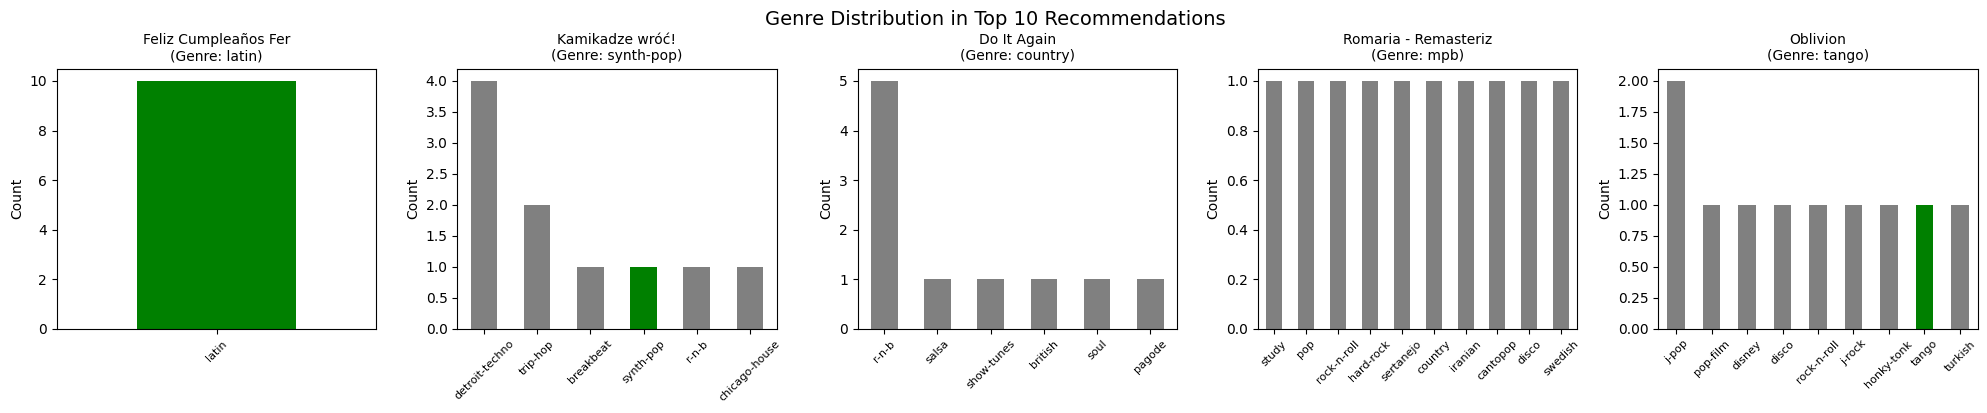

In [9]:
# Visualize genre distribution in recommendations
def visualize_genre_performance(n_test_songs=5):
    """
    Visualize how well recommendations match genres for sample songs.
    """
    np.random.seed(42)
    test_indices = np.random.choice(len(df), n_test_songs, replace=False)
    
    fig, axes = plt.subplots(1, n_test_songs, figsize=(20, 4))
    
    for i, idx in enumerate(test_indices):
        query_song = X[idx].reshape(1, -1)
        query_genre = df.iloc[idx]['track_genre']
        
        # Get neighbors
        distances, indices = knn_model.kneighbors(query_song, n_neighbors=11)
        neighbor_indices = indices[0][1:]
        
        # Get neighbor genres
        neighbor_genres = df.iloc[neighbor_indices]['track_genre'].values
        genre_counts = pd.Series(neighbor_genres).value_counts()
        
        # Plot
        ax = axes[i] if n_test_songs > 1 else axes
        colors = ['green' if g == query_genre else 'gray' for g in genre_counts.index]
        genre_counts.plot(kind='bar', ax=ax, color=colors)
        ax.set_title(f"{df.iloc[idx]['track_name'][:20]}\n(Genre: {query_genre})", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    plt.tight_layout()
    plt.suptitle('Genre Distribution in Top 10 Recommendations', fontsize=14, y=1.02)
    plt.show()

visualize_genre_performance(n_test_songs=5)